Import library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**load Dataset**



we load -> shape ->  This is always the very first step — you can't make any decisions about a dataset until you've actually looked at it.[link text](https://)

In [ ]:
df= pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [ ]:
df.shape

(5000, 13)

In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [ ]:
df.isna().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df= df.drop_duplicates()

In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


**EDA** --> exploratory data

We'll keep this focused — six plots, each answering one specific question about the data, not a wall of charts for the sake of it.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

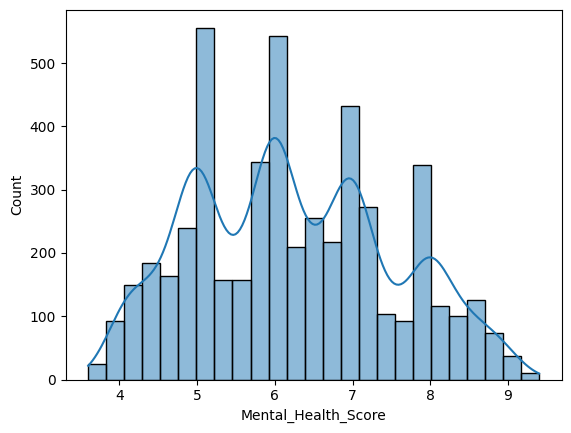

In [ ]:
# 4.1 distribution of target
sns.histplot(df['Mental_Health_Score'],kde=True)


<Axes: >

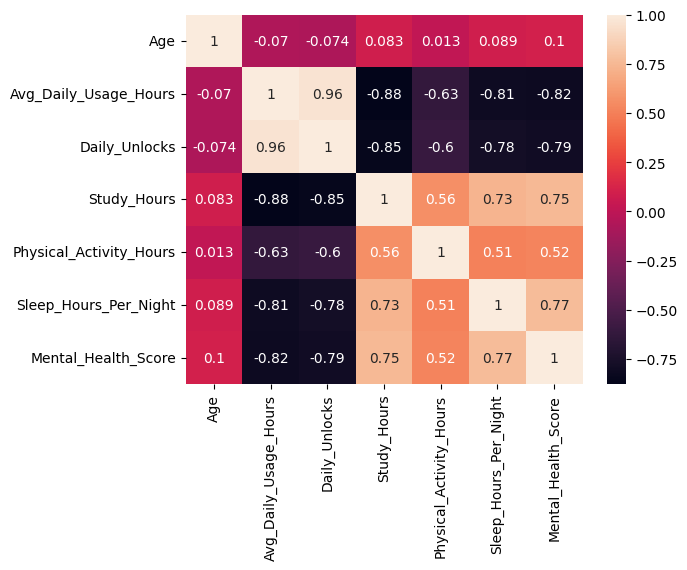

In [ ]:
# 4.2
sns.heatmap(df.corr(numeric_only=True),annot=True)


In [ ]:
# stress vs target
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [ ]:
order =[ 'Low','Medium', 'High','Very High']

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

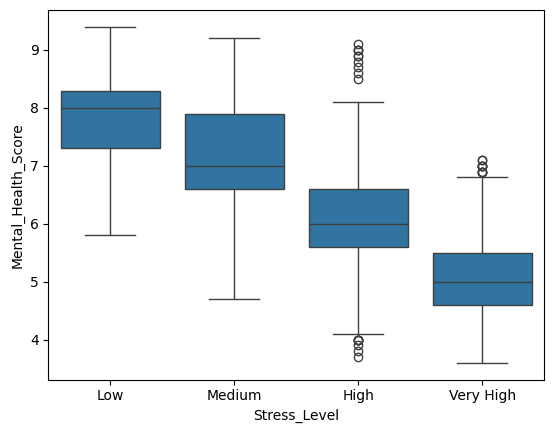

In [ ]:
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

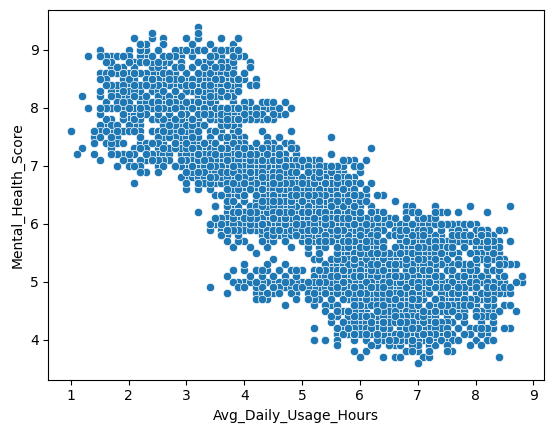

In [ ]:
# daily usage hours and target

df['Avg_Daily_Usage_Hours'].unique()
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

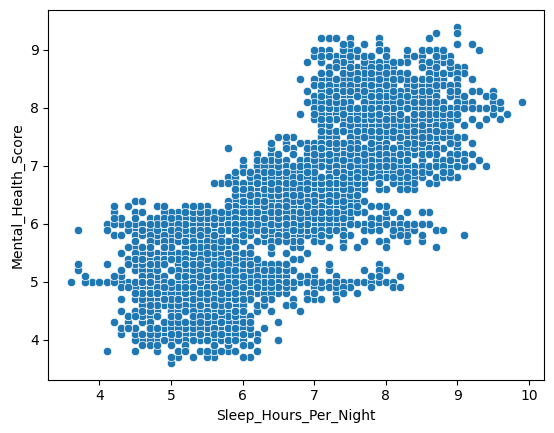

In [ ]:
# sleep vs target
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)

In [ ]:
Platform_counts = df['Most_Used_Platform'].value_counts()

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

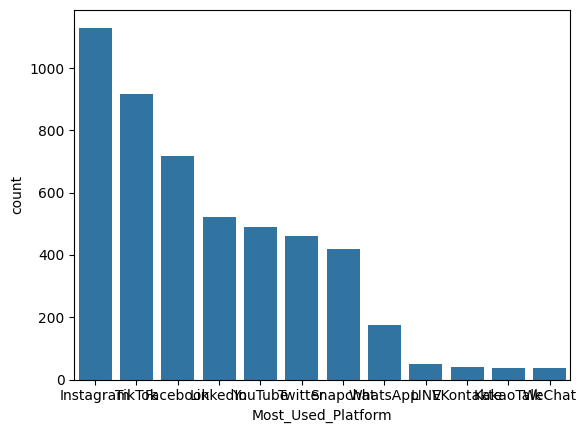

In [ ]:
sns.countplot(
    x=df['Most_Used_Platform'],
    order=df['Most_Used_Platform'].value_counts().index
)

In [ ]:
# checking outliers

In [ ]:
num_ferature = df.select_dtypes(include='number')

In [ ]:
Q1= num_ferature.quantile(0.25)
Q3= num_ferature.quantile(0.75)
IQR= Q3-Q1

lower_bound= Q1 - 1.5*IQR
upper_bound= Q3 + 1.5*IQR

outlier = (num_ferature <lower_bound)  | (num_ferature > upper_bound)\

outlier.sum()

,0
Age,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,2
Physical_Activity_Hours,22
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# data cleaning
# convert the -ve value or unrealistic value in realistic vale
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [ ]:
# skewness
num_cols = df.select_dtypes(include='number')
num_cols.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [ ]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [ ]:
def group_countries(country):
  if country in top_countries:
    return country
  else :
    return 'Other'

In [ ]:
df['group_countries']=df['Country'].apply(group_countries)

In [ ]:
df['group_countries'].value_counts()

,count
group_countries,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
 13  group_countries          4998 non-null   object 
dtypes: float64(5), int64(2), obje

In [ ]:

skews_col = ['Study_Hours']

other_numeric_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night"
]

ordinal_col = ['Stress_Level']

normal_col = [
    "Gender",
    "Academic_Level",
    "Most_Used_Platform",
    "Purpose_Of_Use",
    "group_countries"
]

feature_col = skews_col + other_numeric_cols + ordinal_col + normal_col

X = df[feature_col]

y = df['Mental_Health_Score']

In [ ]:
# skewness => study hours pe aplly hoga ===> log tranformer or standard scaller

In [ ]:
#columns transformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,FunctionTransformer
from sklearn.impute import SimpleImputer

skew_pipeline = Pipeline(steps=[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scale',StandardScaler())
])
# numweric feturw==>
plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])
# ordinal feature ==>
oridnal_pipeline = Pipeline(steps=[
    ('ordinal_encoder',OrdinalEncoder(categories=[['Low','Medium','High','Very High']], handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.float64))
])
# normal feature
nominal_pipeline = Pipeline(steps=[
    ('onehot_encoder',OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('skew_pipeline',skew_pipeline,skews_col),
    ('plain_numeric_pipeline',plain_numeric_pipeline,other_numeric_cols),
    ('oridnal_pipeline',oridnal_pipeline,ordinal_col),
    ('nominal_pipeline',nominal_pipeline,normal_col)
])


In [ ]:
preprocessor

ColumnTransformer(transformers=[('skew_pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('plain_numeric_pipeline',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('oridnal_...
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Stress_Level']),
                                ('nominal_pipeline',
                                 Pipeline(steps=[('onehot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'group_countries'])])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test =train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [ ]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew_pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('plain_numeric_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sle...
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Stress_Level']),
                                                 ('nominal_pipeline',
                                                  Pipeline(steps=[('onehot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'group_countries'])])),
                ('regressor', LinearRegression())])

In [ ]:
lr_pred = lr_pipeline.predict(X_test)
lr_pred_train = lr_pipeline.predict(X_train)

In [ ]:
lr_pred

array([4.61994569, 5.63599478, 4.89939082, ..., 5.20712187, 6.47721615,
       4.94093695])

In [ ]:
lr_r2_testing = r2_score(y_test,lr_pred)
lr_r2_training = r2_score(y_train,lr_pred_train)
lr_mae = mean_absolute_error(y_test,lr_pred)
lr_mse = mean_squared_error(y_test,lr_pred)

In [ ]:
lr_r2_training

0.722010683845954

In [ ]:
lr_r2_testing

0.7413129886502247

In [ ]:
lr_mae

0.5321816918405357

In [ ]:
lr_mse

0.45120561561026

**# random forest (default setting)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

re_pipline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random_forest',RandomForestRegressor())
])

re_pipline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew_pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('plain_numeric_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sle...
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Stress_Level']),
                                                 ('nominal_pipeline',
                                                  Pipeline(steps=[('onehot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'group_countries'])])),
                ('random_forest', RandomForestRegressor())])

In [ ]:
re_pred = re_pipline.predict(X_test)
re_pred_train = re_pipline.predict(X_train)

re_r2_testing = r2_score(y_test,re_pred)
re_r2_training = r2_score(y_train,re_pred_train)
re_mae = mean_absolute_error(y_test,re_pred)
re_mse = mean_squared_error(y_test,re_pred)

In [ ]:
print(f'accuracy of training {re_r2_testing}')
print(f'accuracy of training {re_r2_training}')
print(re_mae)
print(re_mse)
print(re_pred)
print(re_pred_train)

accuracy of training 0.8753412181006839
accuracy of training 0.9809425661591228
0.3490426666666668
0.217431645039394
[4.714 5.578 4.078 ... 4.795 6.602 4.893]
[4.951 6.973 7.469 ... 6.551 5.651 5.712]


**Hyperparameter tunning**

In [ ]:
# from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    'random_forest__n_estimators': [100, 200, 300],
    'random_forest__max_depth': [5, 10, 15],
    'random_forest__min_samples_split': [2, 5, 10],
    'random_forest__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=re_pipline, # Use the pipeline here
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew_pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric_pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unloc...
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'group_countries'])])),
                                             ('random_forest',
                                              RandomForestRegressor())]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random_forest__max_depth': [5, 10, 15],
                                        'random_forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random_forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random_forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, verbose=2)

In [ ]:
random_search.best_params_

{'random_forest__n_estimators': 300,
 'random_forest__min_samples_split': 5,
 'random_forest__min_samples_leaf': 2,
 'random_forest__max_depth': 15}

In [ ]:
re_best_pipeline = random_search.best_estimator_
re_best_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew_pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('plain_numeric_pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Activity_Hours',
                                                   'Sle...
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Stress_Level']),
                                                 ('nominal_pipeline',
                                                  Pipeline(steps=[('onehot_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'group_countries'])])),
                ('random_forest',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=2,
                                       min_samples_split=5,
                                       n_estimators=300))])

In [ ]:
re_best_pred = re_best_pipeline.predict(X_test)

print(f'r2 score of testing {r2_score(y_test,re_best_pred)}')
# print(f'r2 score of training {r2_score(y_train,re_best_pipeline.predict(X_train))}')

r2 score of testing 0.8638397996554531


In [ ]:
re_best_pred

array([4.7835093 , 5.6109072 , 4.15466291, ..., 4.71897365, 6.58948967,
       4.95290403])

In [ ]:
# model evalution

In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, re_pred))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds = random_search.best_estimator_.predict(X_test)
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)

r2_tuned_training = r2_score(y_train, rf_tuned_training_preds)
r2_tuned = r2_score(y_test, rf_tuned_preds)

rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))

# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, re_r2_testing, r2_tuned],
    'Training R2': [lr_r2_training, re_r2_training, r2_tuned_training],
    'MAE': [lr_mae, re_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.741313     0.722011  0.532182  0.671718
1  Random Forest (default)  0.875341     0.980943  0.349043  0.466296
2    Random Forest (tuned)  0.863730     0.954876  0.368757  0.487528


In [ ]:
# save model

import joblib
joblib.dump(re_pipline,'mental_health_model.pkl')

['mental_health_model.pkl']